# MeteoSwiss NWP on ArrayLake — demo notebook

This notebook shows how to read the MeteoSwiss NWP data stored in an ArrayLake-managed icechunk repository.

Run it with the `notebook` Pixi environment:

```bash
pixi run -e notebook jupyter lab notebooks/demo.ipynb
```

Make sure your `ARRAYLAKE_TOKEN` is available in the environment.

In [1]:
import os

import arraylake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import zarr

ORG = "martibosch"
REPO = "meteoswiss-nwp-anl"
TOKEN = os.environ["ARRAYLAKE_TOKEN"]

client = arraylake.Client(token=TOKEN)
repo = client.get_repo(f"{ORG}/{REPO}")
session = repo.readonly_session("main")
store = session.store
print("Connected to", repo)

Connected to <icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: S3 (native)
    bucket: aifs-modal-unibe
    prefix: xcy0r2l5_meteoswiss_nwp_anl
    region: iad
    endpoint_url: https://t3.storage.dev
config: <RepositoryConfig ...>



## Discover groups

In [2]:
root = zarr.open_group(store, mode="r")
print("Top-level groups:", list(root.group_keys()))

Top-level groups: ['ch1-sfc', 'kenda-sfc', 'ch2-ml', 'ch2-sfc']


## Read a surface product (CH1)

In [3]:
ds_ch1_sfc = xr.open_zarr(store, group="ch1-sfc", consolidated=False)
ds_ch1_sfc

<xarray.Dataset> Size: 83MB
Dimensions:   (ref_time: 1, z: 3, cell: 1147980)
Coordinates:
  * ref_time  (ref_time) datetime64[ns] 8B 2026-09-03T06:00:00
  * z         (z) int64 24B 0 2 10
    lon       (cell) float32 5MB dask.array<chunksize=(143498,), meta=np.ndarray>
    lat       (cell) float32 5MB dask.array<chunksize=(143498,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables:
    PMSL      (ref_time, z, cell) float32 14MB dask.array<chunksize=(1, 1, 143498), meta=np.ndarray>
    T_2M      (ref_time, z, cell) float32 14MB dask.array<chunksize=(1, 1, 143498), meta=np.ndarray>
    TOT_PREC  (ref_time, cell) float32 5MB dask.array<chunksize=(1, 143498), meta=np.ndarray>
    TD_2M     (ref_time, z, cell) float32 14MB dask.array<chunksize=(1, 1, 143498), meta=np.ndarray>
    V_10M     (ref_time, z, cell) float32 14MB dask.array<chunksize=(1, 1, 143498), meta=np.ndarray>
    U_10M     (ref_time, z, cell) float32 14MB dask.array<chunksize=(1, 1, 143498), meta=np.ndarray>

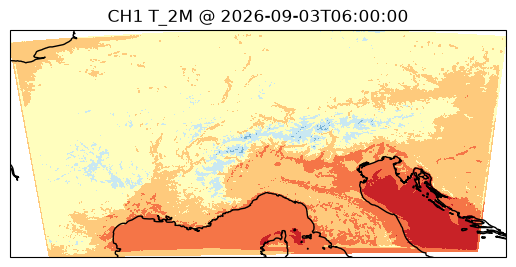

In [4]:
# Plot the latest 2-metre temperature snapshot (unstructured grid)
latest = ds_ch1_sfc.isel(ref_time=-1)

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
da = latest.T_2M.sel(z=2)
ax.tricontourf(
    latest.lon.values,
    latest.lat.values,
    da.values,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
)
ax.coastlines()
ax.set_title(f"CH1 T_2M @ {str(latest.ref_time.values)[:19]}")
plt.show()


## Read a multi-level product (CH2)

In [5]:
ds_ch2_ml = xr.open_zarr(store, group="ch2-ml", consolidated=False)
ds_ch2_ml

<xarray.Dataset> Size: 275MB
Dimensions:   (ref_time: 1, z: 80, cell: 283876)
Coordinates:
  * ref_time  (ref_time) datetime64[ns] 8B 2026-09-03T06:00:00
  * z         (z) int64 640B 1 2 3 4 5 6 7 8 9 10 ... 72 73 74 75 76 77 78 79 80
    lon       (cell) float32 1MB dask.array<chunksize=(70969,), meta=np.ndarray>
    lat       (cell) float32 1MB dask.array<chunksize=(70969,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables:
    T         (ref_time, z, cell) float32 91MB dask.array<chunksize=(1, 10, 35485), meta=np.ndarray>
    U         (ref_time, z, cell) float32 91MB dask.array<chunksize=(1, 10, 35485), meta=np.ndarray>
    V         (ref_time, z, cell) float32 91MB dask.array<chunksize=(1, 10, 35485), meta=np.ndarray>

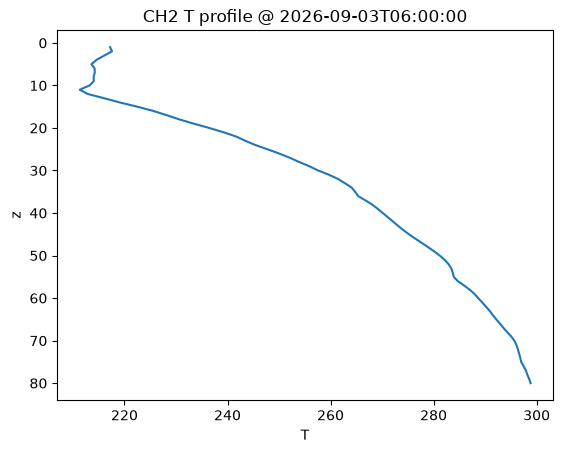

In [6]:
# Temperature profile at a single cell of the latest snapshot
latest_ml = ds_ch2_ml.isel(ref_time=-1)
ncell = latest_ml.sizes["cell"]
profile = latest_ml.isel(cell=ncell // 2)

fig, ax = plt.subplots()
profile.T.plot(y="z", yincrease=False, ax=ax)
ax.set_title(f"CH2 T profile @ {str(profile.ref_time.values)[:19]}")
plt.show()


## Quick overview of all surface products

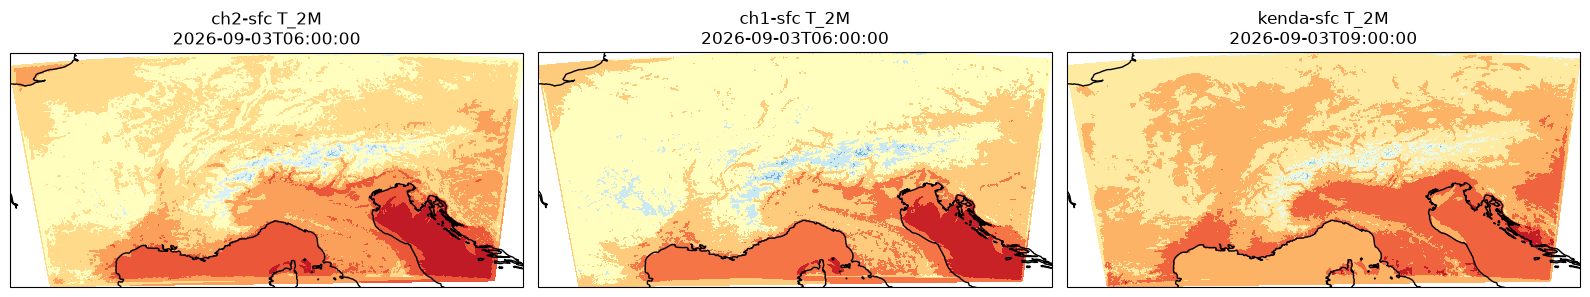

In [7]:
products = ["ch2-sfc", "ch1-sfc", "kenda-sfc"]
var = "T_2M"

fig, axes = plt.subplots(
    1, len(products), figsize=(16, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, group in zip(axes, products):
    ds = xr.open_zarr(store, group=group, consolidated=False)
    latest = ds.isel(ref_time=-1)
    da = latest[var].sel(z=2)
    ax.tricontourf(
        latest.lon.values,
        latest.lat.values,
        da.values,
        transform=ccrs.PlateCarree(),
        cmap="RdYlBu_r",
    )
    ax.coastlines()
    ax.set_title(f"{group} {var}\n{str(latest.ref_time.values)[:19]}")

plt.tight_layout()
plt.show()


## Performance: ArrayLake vs direct OGD fetch

Reading from the ArrayLake repo is typically much faster than fetching the same data from the MeteoSwiss OGD API, because the repo stores the data in Icechunk-managed Zarr chunks close to compute.

In [8]:
import timeit

from meteodatalab import ogd_api

# Time reading T_2M from ArrayLake
def read_arraylake():
    ds = xr.open_zarr(store, group="ch1-sfc", consolidated=False)
    return ds.isel(ref_time=-1).T_2M.sel(z=2).values

# Time fetching the same field from the OGD API
def read_ogd():
    req = ogd_api.Request(
        collection="ogd-forecasting-icon-ch1",
        variable="T_2M",
        reference_datetime="latest",
        perturbed=False,
        horizon="P0DT0H",
    )
    return ogd_api.get_from_ogd(req).values

n = 3
t_arraylake = min(timeit.repeat(read_arraylake, number=1, repeat=n))
t_ogd = min(timeit.repeat(read_ogd, number=1, repeat=n))

print(f"ArrayLake: {t_arraylake:.3f} s")
print(f"OGD API:   {t_ogd:.3f} s")
print(f"Speed-up:  {t_ogd / t_arraylake:.1f}x")


Earthkit-data caching is recommended. See: https://earthkit-data.readthedocs.io/en/latest/examples/cache.html


icon-ch1-eps-202609030900-0-t_2m-ctrl.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=Re4xqHejDnieFl3yr81OOyBxATw%3D&Expires=1788516995: 0.00B [00:00, ?B

icon-ch1-eps-202609030900-0-t_2m-ctrl.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=Re4xqHejDnieFl3yr81OOyBxATw%3D&Expires=1788516995: 1.00MB [00:00, 5

 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 


 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
------------------------------------------------------------------------------------------------------

...

 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
------------------------------------------------------------------------------------------------------

horizontal_constants_icon-ch1-eps.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=LjQoo1nRTMP5dOt9wWGzuFdRFSw%3D&Expires=1791111441: 0.00B [00:00, ?B/s]

horizontal_constants_icon-ch1-eps.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=LjQoo1nRTMP5dOt9wWGzuFdRFSw%3D&Expires=1791111441: 18.0MB [00:00, 189MB

ArrayLake: 0.264 s
OGD API:   0.486 s
Speed-up:  1.8x


 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
---------------------------------------------------------------------------------------------------------------------------------------------------
Please check environment settings and/or use ECCODES_DEFINITION_PATH environment variable for including compatible definitions.edzw version 2.47.3.
---------------------------------------------------------------------------------------------------------------------------------------------------
 
 
------------------------------------------------------------------------------------------------------